Goal / Objective

To identify meaningful relationships between products purchased together by customers, in order to improve sales strategies, product placement, and customer experience through data-driven insights.

---

Business Problem

Retail businesses often have large volumes of transaction data but lack actionable insights about customer buying behavior.

---

Proposed Solution

Use Market Basket Analysis (MBA) powered by Association Rule Mining (Apriori / FP-Growth algorithms) to:

    Detect patterns of co-purchased items.
    
    Discover product combinations with strong support, confidence, and lift values.
    
    Visualize and interpret patterns to make business recommendations.

---

In [1]:

import pandas as pd


    Each row = one customer’s shopping basket (transaction)
    
    Each column = an item in that basket

In [2]:

df = pd.read_csv('Market_Basket_Optimisation.csv',header=None)
df


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,turkey,avocado,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,mineral water,milk,energy bar,whole wheat rice,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,butter,light mayo,fresh bread,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7497,burgers,frozen vegetables,eggs,french fries,magazines,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7498,chicken,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7499,escalope,green tea,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df[:3]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,chutney,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Handle Missing Values

    Replaces NaN with an empty string ''

    This ensures we don’t get errors while converting to lists later.

In [4]:
df.fillna('',axis=1,inplace=True)
df[:3]

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil
1,burgers,meatballs,eggs,,,,,,,,,,,,,,,,,
2,chutney,,,,,,,,,,,,,,,,,,,


In [5]:
from mlxtend.preprocessing import TransactionEncoder

from mlxtend.frequent_patterns import apriori

In [ ]:
# convert the dataframe into a list of list where each inner list represents a transaction.

In [6]:

df_list = df.to_numpy().tolist()
df_list[:3]

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers',
  'meatballs',
  'eggs',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  ''],
 ['chutney',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '',
  '']]


Convert each row (transaction) to a list of items.


In [7]:

dataset = [[item for item in transaction if item] for transaction in df_list]


Each row becomes a list of items purchased in one transaction

Empty cells are removed.

In [9]:
dataset[:2]

[['shrimp',
  'almonds',
  'avocado',
  'vegetables mix',
  'green grapes',
  'whole weat flour',
  'yams',
  'cottage cheese',
  'energy drink',
  'tomato juice',
  'low fat yogurt',
  'green tea',
  'honey',
  'salad',
  'mineral water',
  'salmon',
  'antioxydant juice',
  'frozen smoothie',
  'spinach',
  'olive oil'],
 ['burgers', 'meatballs', 'eggs']]

In [10]:
te = TransactionEncoder()
te

TransactionEncoder()

In [11]:
te_array = te.fit(dataset).transform(dataset)
te_array

array([[False,  True,  True, ...,  True, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False,  True, False]])

In [12]:
final_df = pd.DataFrame(te_array,columns=te.columns_)
final_df

,asparagus,almonds,antioxydant juice,asparagus,avocado,babies food,bacon,barbecue sauce,black tea,blueberries,...,turkey,vegetables mix,water spray,white wine,whole weat flour,whole wheat pasta,whole wheat rice,yams,yogurt cake,zucchini
0,False,True,True,False,True,False,False,False,False,False,...,False,True,False,False,True,False,False,True,False,False
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,True,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7496,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7497,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7498,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
7499,False,False,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


In [13]:
# Use the apriori algorithm and the min_support for finding out items or group of items which have a support greater than the minimum support.

frequent_itemsets_ap = apriori(final_df, min_support=0.01, use_colnames=True)

In [14]:
frequent_itemsets_ap

,support,itemsets
0,0.020397,(almonds)
1,0.033329,(avocado)
2,0.010799,(barbecue sauce)
3,0.014265,(black tea)
4,0.011465,(body spray)
...,...,...
252,0.011065,"(milk, mineral water, ground beef)"
253,0.017064,"(mineral water, ground beef, spaghetti)"
254,0.015731,"(milk, mineral water, spaghetti)"
255,0.010265,"(mineral water, olive oil, spaghetti)"


In [15]:
from mlxtend.frequent_patterns import association_rules

rules_ap = association_rules(frequent_itemsets_ap, metric="confidence", min_threshold=0.2)
rules_ap

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(avocado),(mineral water),0.033329,0.238368,0.011598,0.348000,1.459926,1.0,0.003654,1.168147,0.325896,0.044593,0.143943,0.198329
1,(burgers),(eggs),0.087188,0.179709,0.028796,0.330275,1.837830,1.0,0.013128,1.224818,0.499424,0.120941,0.183552,0.245256
2,(burgers),(french fries),0.087188,0.170911,0.021997,0.252294,1.476173,1.0,0.007096,1.108844,0.353384,0.093168,0.098160,0.190499
3,(burgers),(green tea),0.087188,0.132116,0.017464,0.200306,1.516139,1.0,0.005945,1.085270,0.372947,0.086526,0.078570,0.166248
4,(burgers),(milk),0.087188,0.129583,0.017864,0.204893,1.581175,1.0,0.006566,1.094717,0.402667,0.089812,0.086522,0.171377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,"(mineral water, spaghetti)",(milk),0.059725,0.129583,0.015731,0.263393,2.032623,1.0,0.007992,1.181657,0.540294,0.090630,0.153731,0.192396
158,"(mineral water, olive oil)",(spaghetti),0.027596,0.174110,0.010265,0.371981,2.136468,1.0,0.005460,1.315071,0.547034,0.053621,0.239585,0.215470
159,"(olive oil, spaghetti)",(mineral water),0.022930,0.238368,0.010265,0.447674,1.878079,1.0,0.004799,1.378954,0.478514,0.040892,0.274813,0.245370
160,"(mineral water, pancakes)",(spaghetti),0.033729,0.174110,0.011465,0.339921,1.952333,1.0,0.005593,1.251198,0.504819,0.058384,0.200766,0.202885


In [16]:
# Convert the rules obtained into a dataframe for better visualisation
result = pd.DataFrame(rules_ap)
result

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(avocado),(mineral water),0.033329,0.238368,0.011598,0.348000,1.459926,1.0,0.003654,1.168147,0.325896,0.044593,0.143943,0.198329
1,(burgers),(eggs),0.087188,0.179709,0.028796,0.330275,1.837830,1.0,0.013128,1.224818,0.499424,0.120941,0.183552,0.245256
2,(burgers),(french fries),0.087188,0.170911,0.021997,0.252294,1.476173,1.0,0.007096,1.108844,0.353384,0.093168,0.098160,0.190499
3,(burgers),(green tea),0.087188,0.132116,0.017464,0.200306,1.516139,1.0,0.005945,1.085270,0.372947,0.086526,0.078570,0.166248
4,(burgers),(milk),0.087188,0.129583,0.017864,0.204893,1.581175,1.0,0.006566,1.094717,0.402667,0.089812,0.086522,0.171377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,"(mineral water, spaghetti)",(milk),0.059725,0.129583,0.015731,0.263393,2.032623,1.0,0.007992,1.181657,0.540294,0.090630,0.153731,0.192396
158,"(mineral water, olive oil)",(spaghetti),0.027596,0.174110,0.010265,0.371981,2.136468,1.0,0.005460,1.315071,0.547034,0.053621,0.239585,0.215470
159,"(olive oil, spaghetti)",(mineral water),0.022930,0.238368,0.010265,0.447674,1.878079,1.0,0.004799,1.378954,0.478514,0.040892,0.274813,0.245370
160,"(mineral water, pancakes)",(spaghetti),0.033729,0.174110,0.011465,0.339921,1.952333,1.0,0.005593,1.251198,0.504819,0.058384,0.200766,0.202885


In [17]:
result.sort_values(by='lift',inplace=True,ascending=False)
result

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
75,(herb & pepper),(ground beef),0.049460,0.098254,0.015998,0.323450,3.291994,1.0,0.011138,1.332860,0.732460,0.121457,0.249734,0.243136
153,"(mineral water, spaghetti)",(ground beef),0.059725,0.098254,0.017064,0.285714,2.907928,1.0,0.011196,1.262445,0.697788,0.121097,0.207886,0.229696
69,(tomatoes),(frozen vegetables),0.068391,0.095321,0.016131,0.235867,2.474464,1.0,0.009612,1.183930,0.639616,0.109304,0.155355,0.202549
67,(shrimp),(frozen vegetables),0.071457,0.095321,0.016664,0.233209,2.446574,1.0,0.009853,1.179825,0.636767,0.111012,0.152417,0.204017
143,"(milk, mineral water)",(frozen vegetables),0.047994,0.095321,0.011065,0.230556,2.418737,1.0,0.006490,1.175757,0.616132,0.083669,0.149484,0.173320
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,(green tea),(spaghetti),0.132116,0.174110,0.026530,0.200807,1.153335,1.0,0.003527,1.033405,0.153188,0.094852,0.032325,0.176590
46,(ground beef),(eggs),0.098254,0.179709,0.019997,0.203528,1.132539,1.0,0.002340,1.029905,0.129779,0.077519,0.029037,0.157402
19,(chocolate),(eggs),0.163845,0.179709,0.033196,0.202604,1.127397,1.0,0.003751,1.028711,0.135143,0.106959,0.027910,0.193661
73,(green tea),(mineral water),0.132116,0.238368,0.031063,0.235116,0.986357,1.0,-0.000430,0.995748,-0.015688,0.091516,-0.004270,0.182715


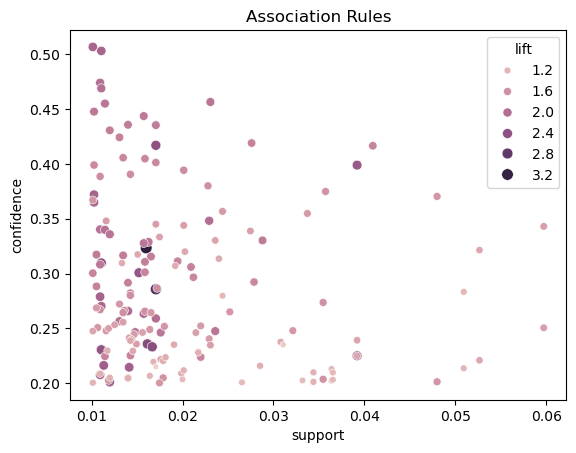

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x='support', y='confidence', size='lift', hue='lift', data=result)
plt.title('Association Rules')
plt.show()

| Metric                  | Meaning                                                             |
| ----------------------- | ------------------------------------------------------------------- |
| **x-axis (support)**    | Frequency of the itemset appearing in transactions                  |
| **y-axis (confidence)** | Strength of the rule (likelihood of consequent given antecedent)    |
| **size (lift)**         | Strength of association (>1 means positive correlation)             |
| **color (hue)**         | Represents different lift values (gradient shows strength visually) |


Each dot = one rule

Larger & darker dots = stronger association